# Phase 2: Palace C-matrix of P1, P2, P3

Env: `chip`. Typed steps: `devnotes/phase2.md`.

`quantromon.sim.palace` is the engine (same result every time from a script). **This notebook is where you look**: conductors, Gmsh mesh, local refinement, then Palace.

No on-chip ground. Metals include L2D2100 Al (meander cut at y = 0) and L2D2400 JJ fingers (0.2 um gaps). L3 is out. Confirm three islands before running Palace. In Gmsh, zoom to the origin for the meander, then to about 2 um wide for the JJ gaps.

Kishor \(C_J \approx 56\) fF is those 0.2 um gaps, not the Ta pads. Notes: `devnotes/QuantroTa_01_layout_notes.md`.

In [5]:
from quantromon.paths import outdir, repo_root

OUT = outdir(repo_root() / "out")
print("out", OUT)

cwd /home/hm/QpiAi/Github/device_design/quantromon


size_z 430um
ground omitted True
terminal map: {1: 'P3', 2: 'P1', 3: 'P2'}
terminals 3


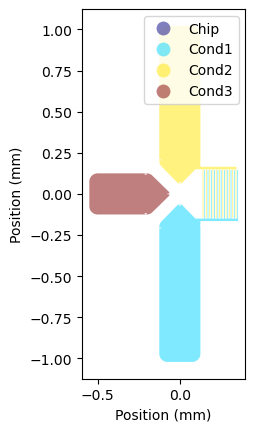

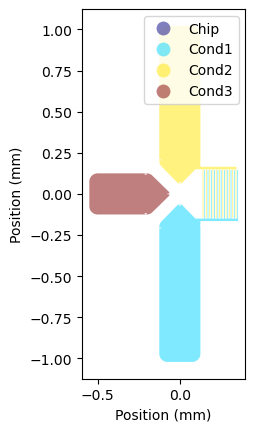

In [6]:
%matplotlib inline
from quantromon.sim.palace import build_cap_sim, prepare
from quantromon.geometry.pads import make_design

design = make_design()
print("size_z", design.chips.main.size.size_z)
cap_sim = build_cap_sim(design, coarse=True)
print("ground omitted", cap_sim._ground_plane.get("omit"))
fig = prepare(cap_sim, OUT / "phase2_conductors.png")
print("terminals", len(cap_sim._cur_cap_terminals))
fig

## Look at the mesh (before Palace)

Same pattern as Murat’s notebook: `prepare` writes the `.msh`, then `GMSH_Navigator.open_GUI()`, and only later `cap_sim.run()`.

Use the **coarse** mesh (cell above, `coarse=True`): 5 um on the IDC. The Al meander is in the metal; zoom Gmsh to about x = -80 to 40 um, y = -80 to 80 um.

Do **not** put a 2 um size field on the whole Al box (that wrote a 3 GB mesh here). Do not open a leftover 2 um IDC file if `quantrota_pads_cap.msh` is ~1.7 GB.

`plot_mesh` is the inline matplotlib version (no extra window). The next cell is the native Gmsh GUI. Close Gmsh to get the kernel back.

mesh file: /home/hm/QpiAi/Github/device_design/quantromon/sims/quantrota_pads_cap/quantrota_pads_cap.msh size_MB 108.1


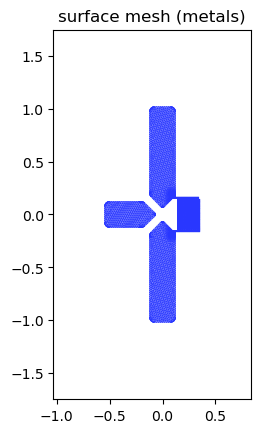

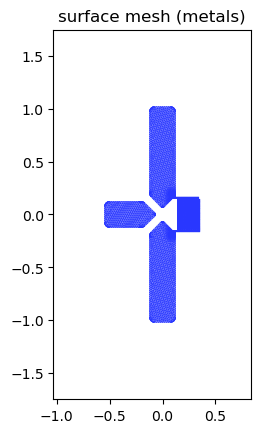

In [7]:
from quantromon.sim.palace import plot_mesh, mesh_file

p = mesh_file(cap_sim)
print("mesh file:", p, "size_MB", round(p.stat().st_size / 1e6, 1))
if p.stat().st_size > 4e8:
    raise RuntimeError(
        "mesh is too large to plot on this machine. "
        "Re-run the prepare cell with coarse=True first."
    )
fig, ax = plot_mesh(cap_sim)
ax.set_aspect("equal")
ax.set_title("surface mesh (metals)")
fig

In [8]:
# Native Gmsh window, same as Murat:
#   gmsh_nav = GMSH_Navigator(cap_sim.path_mesh)
#   gmsh_nav.open_GUI()
# Blocks the kernel until you close Gmsh.
from quantromon.sim.palace import mesh_file, open_gmsh_gui

p = mesh_file(cap_sim)
print("mesh file:", p, "size_MB", round(p.stat().st_size / 1e6, 1))
if p.stat().st_size > 4e8:
    raise RuntimeError(
        "mesh is too large for the Gmsh GUI here. "
        "Re-run the prepare cell with coarse=True first."
    )
open_gmsh_gui(cap_sim, hide_box=True, hide_substrate=False)

mesh file: /home/hm/QpiAi/Github/device_design/quantromon/sims/quantrota_pads_cap/quantrota_pads_cap.msh size_MB 108.1


## Tighten the mesh in a box

Coordinates in **microns**, same as the DXF / `phase1_islands.png`. Example: denser mesh on the IDC (already partly refined). After this, `prepare` remeshes. Then re-run the mesh plot.

In [ ]:
from quantromon.sim.palace import refine_rectangle, prepare

# Optional. 2 um on the whole IDC is what OOM'd Palace (1.7 GB msh).
# If you try a denser patch, stay around 4 um, then re-run the mesh plot.
# Do not run Palace on this box after a 2 um remesh.

# refine_rectangle(cap_sim, 80, -200, 370, 200, min_um=4.0, max_um=12.0)
# fig = prepare(cap_sim, OUT / "phase2_conductors.png")
# print("terminals", len(cap_sim._cur_cap_terminals))
# fig

## Run Palace

Only after the conductor figure still shows three islands.

In [ ]:
# import numpy as np
# from quantromon.sim.palace import interpret_maxwell_fF
# C = cap_sim.run()
# C_fF = np.asarray(C, dtype=float) * 1e15
# print(C_fF)
# print(interpret_maxwell_fF(C_fF, cap_sim.terminal_names))
# np.savetxt(OUT / "phase2_C_fF.csv", C_fF, delimiter=",")